<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/Modul_11_Decision_Tree_%26_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import tree
from graphviz import Source
from sklearn. tree import export_graphviz
import os

In [ ]:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path. join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

In [ ]:
features = [[1,1,7],[1,0,12],[0,1,18],[0,1,35],[1,1,38],[1,0,50], [0,0,83]]
feature_names = ["Suka Cilok", "Suka Kopi", "Usia"]
targets = [0,0,1,1,1,0,0]
class_names = ["Tidak Suka BTS", "Suka BTS"]

In [ ]:
classifier = tree.DecisionTreeClassifier()
classifier = classifier.fit(features, targets)

print(classifier.predict([[1,1,15]]))

[1]


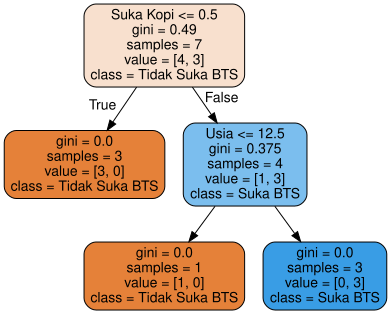

In [ ]:
export_graphviz(
classifier,
out_file=os.path. join(IMAGES_PATH, "BTS.dot"),
feature_names=feature_names,
class_names=class_names,
rounded=True,
filled=True)

Source.from_file(os.path.join(IMAGES_PATH, "BTS.dot"))

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length dan width
y = iris.target

tree_clf = DecisionTreeClassifier()
tree_clf.fit(X, y)

DecisionTreeClassifier()

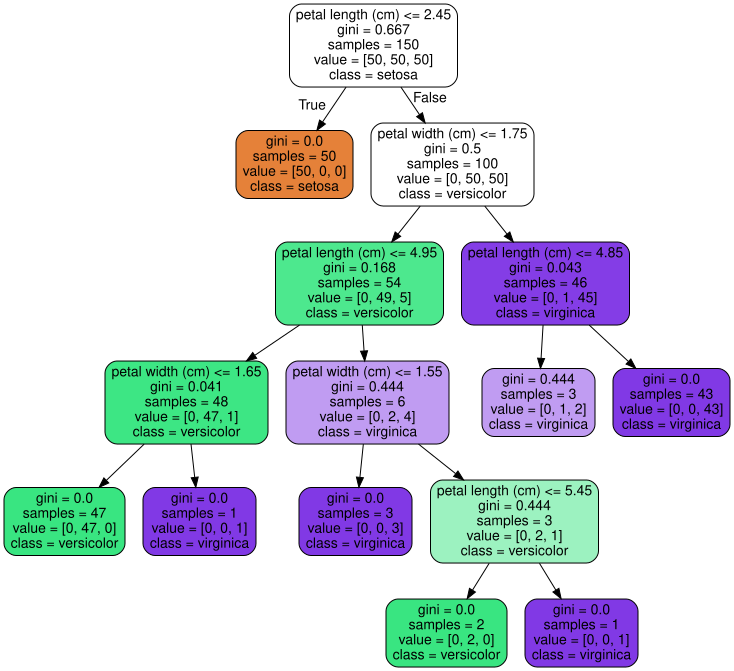

In [ ]:
from graphviz import Source
from sklearn. tree import export_graphviz

export_graphviz(
tree_clf,
out_file=os.path. join(IMAGES_PATH, "iris_tree.dot"),
feature_names=iris. feature_names [2:],
class_names=iris. target_names,
rounded=True,
filled=True
)

Source.from_file(os.path.join(IMAGES_PATH, "iris_tree.dot"))

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

In [ ]:
X = iris.data
y = iris.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =.1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier()

In [ ]:
classifier. fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
predictions = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, predictions))

1.0


In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_SIB2G_1.csv to Dataset_SIB2G_1.csv


In [ ]:
# LOAD DATASET
df = pd.read_csv('/content/Dataset_SIB2G_1.csv',
                 sep=None,
                 engine='python')

print("Jumlah Data :", df.shape)
print(df.head())

Jumlah Data : (21, 17)
                             Nama Tempat Lahir Tanggal Lahir Jenis Kelamin  \
0           Pratama Angga Saputra       Malang    10/07/2005     Laki-Laki   
1  Muchammad Nabil Haykal Widarto  Kota Malang    22/03/2004     Laki-Laki   
2              Moh. Rafael Abrari     Lamongan    27/11/2006     Laki-Laki   
3          Muhamad Miftahul Akmal      Cilegon    05/03/2005     Laki-Laki   
4     Narendra Daniswara Alamsyah   Bojonegoro    16/02/2006     Laki-Laki   

   Tinggi Badan (cm) Berat Badan (kg)    Kota Asal Jenis Kendaraan Utama  \
0                165             52,5       Malang                 Motor   
1                175              123  Kota Malang                 Motor   
2                173               55     Lamongan                 Motor   
3                168               70      Cilegon                 Motor   
4                166               64   Bojonegoro                 Motor   

  IPK Semester Kemarin MBTI (kepribadian) Waktu Pro

In [ ]:
# Menentukan Target
target = "Jenis Kelamin"

In [ ]:
# Encoding data kategorik
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# Memisahkan fitur dan target
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
# Standardisasi Data (Penting untuk KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Decision Tree
print("\n===== DECISION TREE =====")

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", round(acc_dt*100,2), "%")
print(classification_report(y_test, y_pred_dt))


===== DECISION TREE =====
Accuracy : 57.14 %
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.50      0.67      0.57         3

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



In [ ]:
# KNN EUCLIDEAN
print("\n===== KNN EUCLIDEAN =====")

for k in [1,3,5,7,9]:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print(f"K = {k} --> Accuracy = {acc*100:.2f}%")


===== KNN EUCLIDEAN =====
K = 1 --> Accuracy = 71.43%
K = 3 --> Accuracy = 71.43%
K = 5 --> Accuracy = 71.43%
K = 7 --> Accuracy = 57.14%
K = 9 --> Accuracy = 28.57%


In [ ]:
# KNN MINKOWSKI
print("\n===== KNN MINKOWSKI =====")

for k in [1,3,5,7,9]:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print(f"K = {k} --> Accuracy = {acc*100:.2f}%")



===== KNN MINKOWSKI =====
K = 1 --> Accuracy = 71.43%
K = 3 --> Accuracy = 71.43%
K = 5 --> Accuracy = 71.43%
K = 7 --> Accuracy = 57.14%
K = 9 --> Accuracy = 28.57%


In [ ]:
# Perbandingan Terbaik
print("\n===== KNN DETAIL (K=3) =====")

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean'
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


===== KNN DETAIL (K=3) =====
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.67      0.67      0.67         3

    accuracy                           0.71         7
   macro avg       0.71      0.71      0.71         7
weighted avg       0.71      0.71      0.71         7

